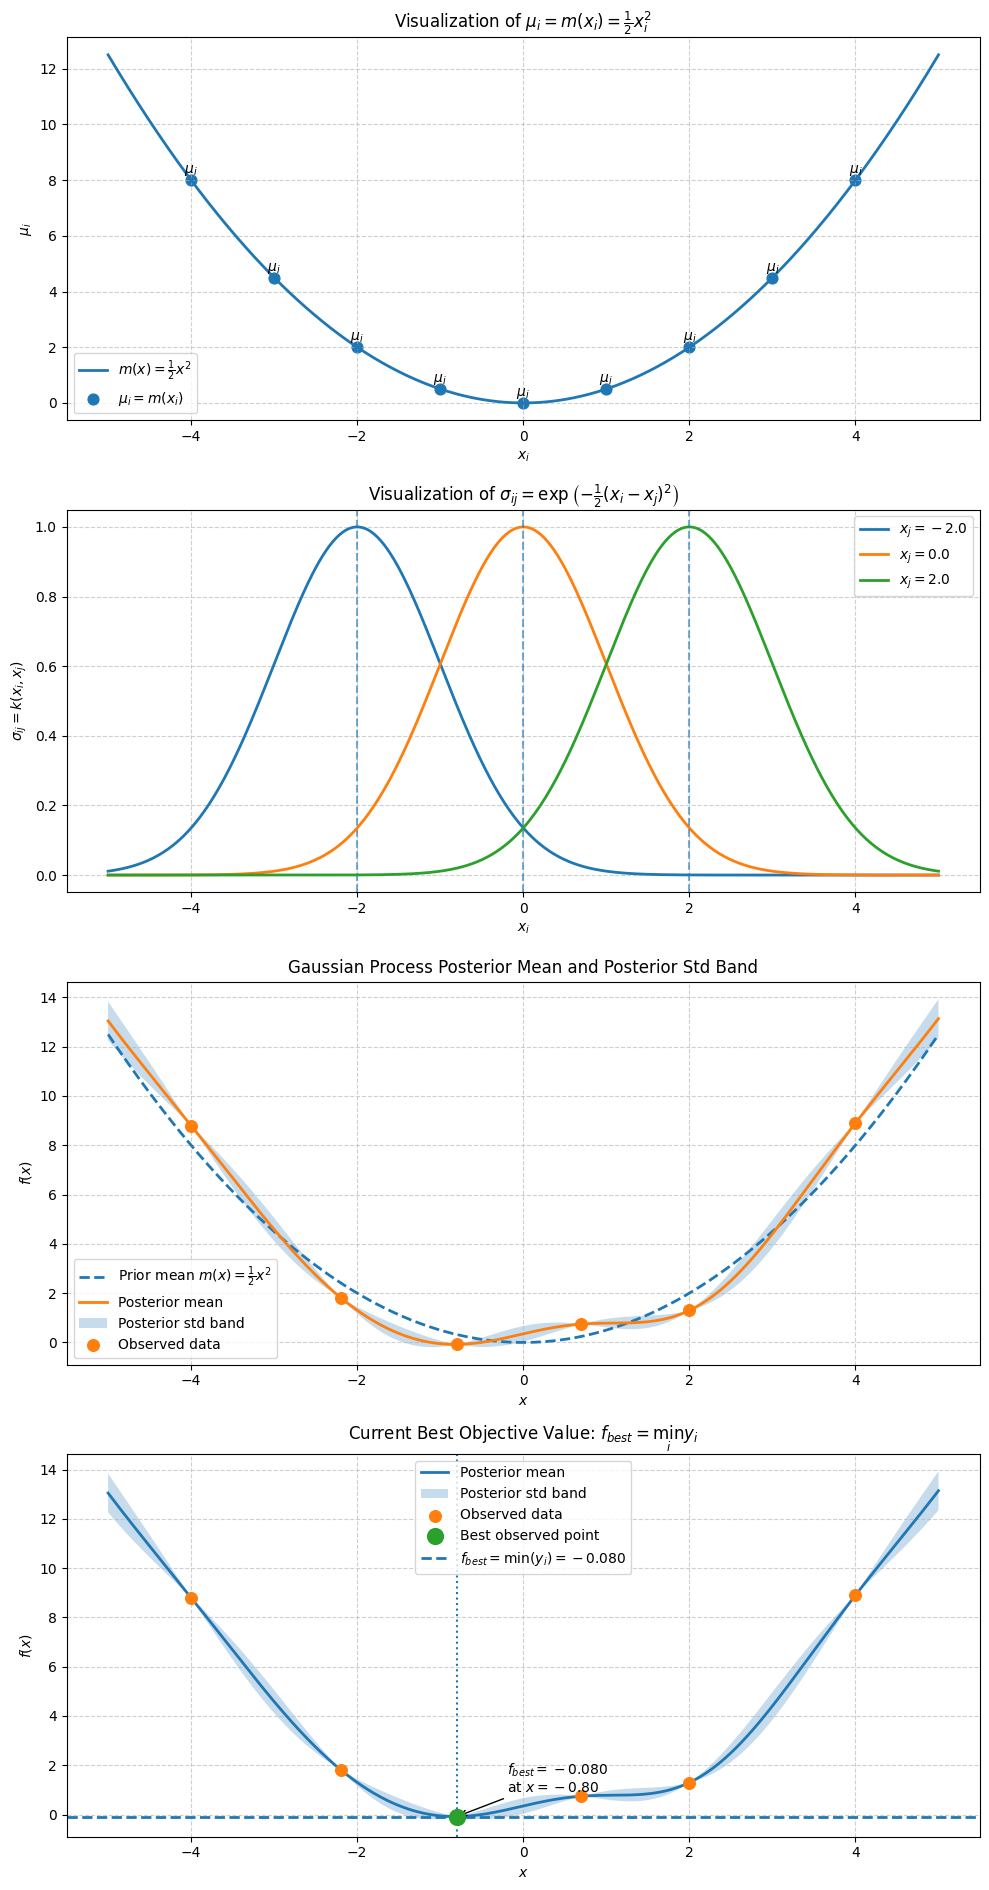

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Mean function
# m(x) = 0.5 * x^2
# ============================================================
def mean_function(x):
    return 0.5 * x**2

# ============================================================
# 2. Covariance / kernel function
# k(x, x') = exp( -0.5 * (x - x')^2 )
# ============================================================
def kernel_function(x1, x2):
    x1 = np.atleast_1d(x1)
    x2 = np.atleast_1d(x2)
    return np.exp(-0.5 * (x1[:, None] - x2[None, :])**2)

# ============================================================
# 3. GP posterior computation
# ============================================================
def gp_posterior(x_train, y_train, x_test, noise=1e-6):
    m_train = mean_function(x_train)
    m_test = mean_function(x_test)

    K_xx = kernel_function(x_train, x_train) + noise * np.eye(len(x_train))
    K_xs = kernel_function(x_train, x_test)
    K_sx = kernel_function(x_test, x_train)
    K_ss = kernel_function(x_test, x_test)

    K_xx_inv = np.linalg.inv(K_xx)

    posterior_mean = m_test + K_sx @ K_xx_inv @ (y_train - m_train)
    posterior_cov = K_ss - K_sx @ K_xx_inv @ K_xs

    posterior_var = np.clip(np.diag(posterior_cov), 0.0, None)
    posterior_std = np.sqrt(posterior_var)

    return posterior_mean, posterior_std

# ============================================================
# 4. Data for mean-function visualization
# ============================================================
x_i_points = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4], dtype=float)
mu_i_points = mean_function(x_i_points)

x_dense = np.linspace(-5, 5, 500)
mu_dense = mean_function(x_dense)

# ============================================================
# 5. Data for covariance-entry visualization
# ============================================================
x_i_curve = np.linspace(-5, 5, 500)
x_j_list = [-2.0, 0.0, 2.0]

# ============================================================
# 6. Training data for GP posterior visualization
# ============================================================
x_train = np.array([-4.0, -2.2, -0.8, 0.7, 2.0, 4.0], dtype=float)
y_train = mean_function(x_train) + np.array([0.8, -0.6, -0.4, 0.5, -0.7, 0.9])

x_test = np.linspace(-5, 5, 500)

posterior_mean, posterior_std = gp_posterior(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    noise=1e-6
)

prior_mean_test = mean_function(x_test)

# ============================================================
# 7. f_best calculation for minimization
# f_best = min_i y_i
# ============================================================
best_idx = np.argmin(y_train)
x_best = x_train[best_idx]
f_best = y_train[best_idx]

# ============================================================
# 8. Create one figure with four subplots
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(10, 19))

# ============================================================
# [1] mu_i visualization
# ============================================================
axes[0].plot(
    x_dense,
    mu_dense,
    linewidth=2,
    label=r'$m(x)=\frac{1}{2}x^2$'
)

axes[0].scatter(
    x_i_points,
    mu_i_points,
    s=60,
    label=r'$\mu_i = m(x_i)$'
)

for x_val, mu_val in zip(x_i_points, mu_i_points):
    axes[0].text(
        x_val,
        mu_val + 0.25,
        r'$\mu_i$',
        ha='center',
        fontsize=10
    )

axes[0].set_xlabel(r'$x_i$')
axes[0].set_ylabel(r'$\mu_i$')
axes[0].set_title(r'Visualization of $\mu_i = m(x_i) = \frac{1}{2}x_i^2$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# ============================================================
# [2] sigma_ij visualization
# ============================================================
for x_j in x_j_list:
    sigma_ij = np.exp(-0.5 * (x_i_curve - x_j)**2)
    axes[1].plot(
        x_i_curve,
        sigma_ij,
        linewidth=2,
        label=rf'$x_j = {x_j}$'
    )
    axes[1].axvline(
        x=x_j,
        linestyle='--',
        alpha=0.6
    )

axes[1].set_xlabel(r'$x_i$')
axes[1].set_ylabel(r'$\sigma_{ij} = k(x_i, x_j)$')
axes[1].set_title(
    r'Visualization of $\sigma_{ij} = \exp\left(-\frac{1}{2}(x_i-x_j)^2\right)$'
)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# ============================================================
# [3] GP posterior mean + std band
# ============================================================
axes[2].plot(
    x_test,
    prior_mean_test,
    linestyle='--',
    linewidth=2,
    label=r'Prior mean $m(x)=\frac{1}{2}x^2$'
)

axes[2].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[2].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[2].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$f(x)$')
axes[2].set_title('Gaussian Process Posterior Mean and Posterior Std Band')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

# ============================================================
# [4] f_best visualization
# ============================================================
axes[3].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[3].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[3].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[3].scatter(
    x_best,
    f_best,
    s=130,
    zorder=4,
    label='Best observed point'
)

axes[3].axhline(
    y=f_best,
    linestyle='--',
    linewidth=2,
    label=rf'$f_{{best}} = \min(y_i) = {f_best:.3f}$'
)

axes[3].axvline(
    x=x_best,
    linestyle=':',
    linewidth=1.5
)

axes[3].annotate(
    rf'$f_{{best}}={f_best:.3f}$' + '\n' + rf'at $x={x_best:.2f}$',
    xy=(x_best, f_best),
    xytext=(x_best + 0.6, f_best + 1.0),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10
)

axes[3].set_xlabel(r'$x$')
axes[3].set_ylabel(r'$f(x)$')
axes[3].set_title(r'Current Best Objective Value: $f_{best} = \min_i y_i$')
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].legend()

# ============================================================
# 9. Layout and show
# ============================================================
plt.tight_layout()
plt.show()

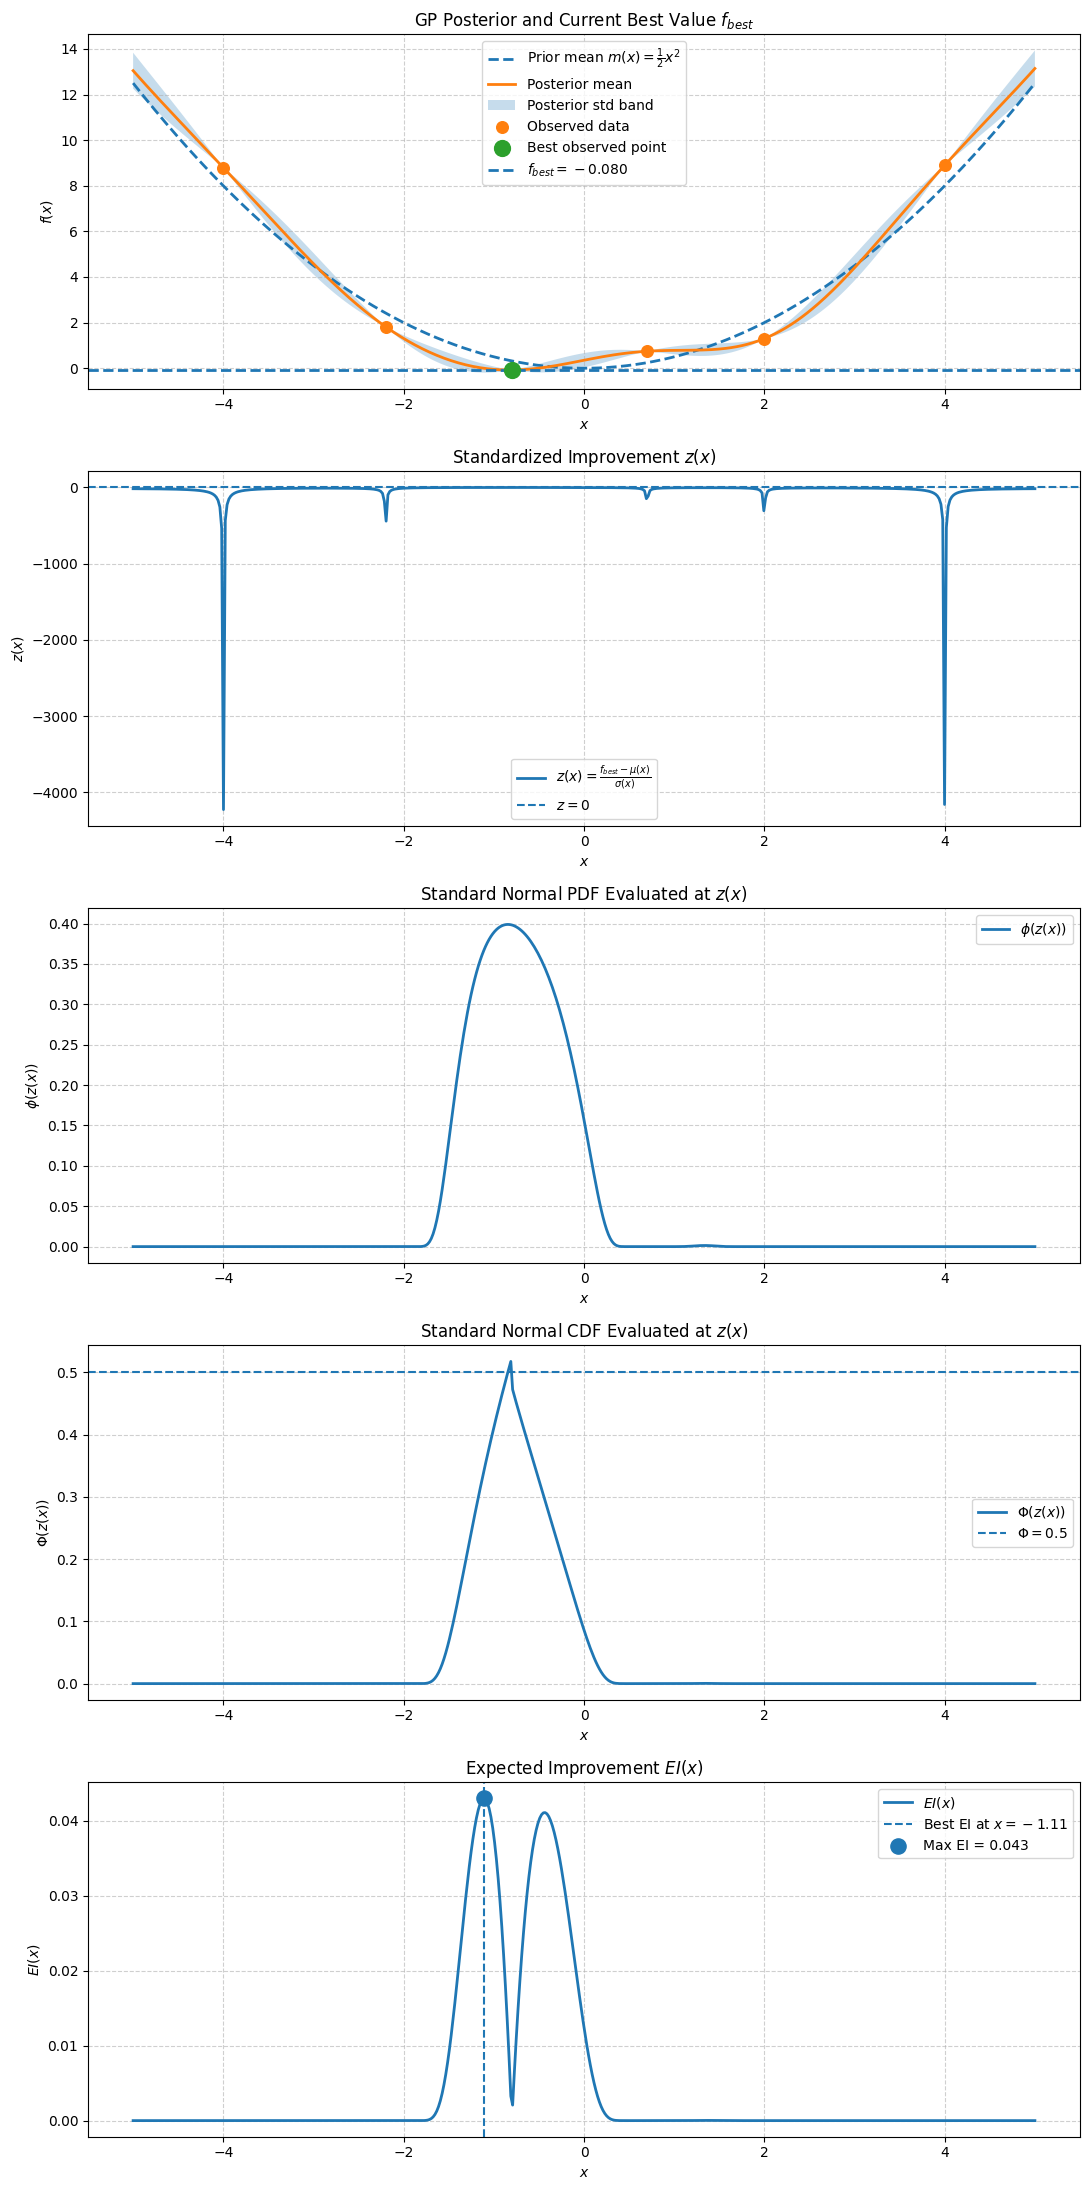

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf

# ============================================================
# 1. Mean function
# m(x) = 0.5 * x^2
# ============================================================
def mean_function(x):
    return 0.5 * x**2

# ============================================================
# 2. Covariance / kernel function
# k(x, x') = exp( -0.5 * (x - x')^2 )
# ============================================================
def kernel_function(x1, x2):
    x1 = np.atleast_1d(x1)
    x2 = np.atleast_1d(x2)
    return np.exp(-0.5 * (x1[:, None] - x2[None, :])**2)

# ============================================================
# 3. GP posterior computation
# ============================================================
def gp_posterior(x_train, y_train, x_test, noise=1e-6):
    m_train = mean_function(x_train)
    m_test = mean_function(x_test)

    K_xx = kernel_function(x_train, x_train) + noise * np.eye(len(x_train))
    K_xs = kernel_function(x_train, x_test)
    K_sx = kernel_function(x_test, x_train)
    K_ss = kernel_function(x_test, x_test)

    K_xx_inv = np.linalg.inv(K_xx)

    posterior_mean = m_test + K_sx @ K_xx_inv @ (y_train - m_train)
    posterior_cov = K_ss - K_sx @ K_xx_inv @ K_xs

    posterior_var = np.clip(np.diag(posterior_cov), 0.0, None)
    posterior_std = np.sqrt(posterior_var)

    return posterior_mean, posterior_std

# ============================================================
# 4. Standard normal PDF / CDF
# ============================================================
def phi(z):
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * z**2)

def Phi(z):
    z = np.asarray(z)
    return 0.5 * (1.0 + np.vectorize(erf)(z / np.sqrt(2.0)))

# ============================================================
# 5. Expected Improvement for minimization
# EI(x) = (f_best - mu(x)) Phi(z) + sigma(x) phi(z)
# ============================================================
def expected_improvement(mu, sigma, f_best):
    sigma_safe = np.maximum(sigma, 1e-12)
    z = (f_best - mu) / sigma_safe
    ei = (f_best - mu) * Phi(z) + sigma_safe * phi(z)
    return ei, z

# ============================================================
# 6. Example observed data
# ============================================================
x_train = np.array([-4.0, -2.2, -0.8, 0.7, 2.0, 4.0], dtype=float)
x_perturbation = np.array([0.8, -0.6, -0.4, 0.5, -0.7, 0.9], dtype=float)
y_train = mean_function(x_train) + x_perturbation

x_test = np.linspace(-5, 5, 500)

posterior_mean, posterior_std = gp_posterior(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    noise=1e-6
)

prior_mean_test = mean_function(x_test)

# ============================================================
# 7. Current best objective value for minimization
# ============================================================
best_idx = np.argmin(y_train)
x_best = x_train[best_idx]
f_best = y_train[best_idx]

# ============================================================
# 8. z(x), phi(z(x)), Phi(z(x)), EI(x)
# ============================================================
ei_values, z_values = expected_improvement(
    mu=posterior_mean,
    sigma=posterior_std,
    f_best=f_best
)

phi_of_zx = phi(z_values)
Phi_of_zx = Phi(z_values)

# Candidate suggested by EI
ei_best_idx = np.argmax(ei_values)
x_ei_best = x_test[ei_best_idx]
ei_best = ei_values[ei_best_idx]

# ============================================================
# 9. Plot
# ============================================================
fig, axes = plt.subplots(5, 1, figsize=(11, 22))

# ------------------------------------------------------------
# [1] GP posterior mean + std band + f_best
# ------------------------------------------------------------
axes[0].plot(
    x_test,
    prior_mean_test,
    linestyle='--',
    linewidth=2,
    label=r'Prior mean $m(x)=\frac{1}{2}x^2$'
)

axes[0].plot(
    x_test,
    posterior_mean,
    linewidth=2,
    label='Posterior mean'
)

axes[0].fill_between(
    x_test,
    posterior_mean - posterior_std,
    posterior_mean + posterior_std,
    alpha=0.25,
    label='Posterior std band'
)

axes[0].scatter(
    x_train,
    y_train,
    s=70,
    zorder=3,
    label='Observed data'
)

axes[0].scatter(
    x_best,
    f_best,
    s=130,
    zorder=4,
    label='Best observed point'
)

axes[0].axhline(
    y=f_best,
    linestyle='--',
    linewidth=2,
    label=rf'$f_{{best}} = {f_best:.3f}$'
)

axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f(x)$')
axes[0].set_title(r'GP Posterior and Current Best Value $f_{best}$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# ------------------------------------------------------------
# [2] z(x)
# ------------------------------------------------------------
axes[1].plot(
    x_test,
    z_values,
    linewidth=2,
    label=r'$z(x)=\frac{f_{best}-\mu(x)}{\sigma(x)}$'
)

axes[1].axhline(
    y=0.0,
    linestyle='--',
    linewidth=1.5,
    label=r'$z=0$'
)

axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$z(x)$')
axes[1].set_title(r'Standardized Improvement $z(x)$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# ------------------------------------------------------------
# [3] phi(z(x))
# ------------------------------------------------------------
axes[2].plot(
    x_test,
    phi_of_zx,
    linewidth=2,
    label=r'$\phi(z(x))$'
)

axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$\phi(z(x))$')
axes[2].set_title(r'Standard Normal PDF Evaluated at $z(x)$')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

# ------------------------------------------------------------
# [4] Phi(z(x))
# ------------------------------------------------------------
axes[3].plot(
    x_test,
    Phi_of_zx,
    linewidth=2,
    label=r'$\Phi(z(x))$'
)

axes[3].axhline(
    y=0.5,
    linestyle='--',
    linewidth=1.5,
    label=r'$\Phi=0.5$'
)

axes[3].set_xlabel(r'$x$')
axes[3].set_ylabel(r'$\Phi(z(x))$')
axes[3].set_title(r'Standard Normal CDF Evaluated at $z(x)$')
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].legend()

# ------------------------------------------------------------
# [5] EI(x)
# ------------------------------------------------------------
axes[4].plot(
    x_test,
    ei_values,
    linewidth=2,
    label=r'$EI(x)$'
)

axes[4].axvline(
    x=x_ei_best,
    linestyle='--',
    linewidth=1.5,
    label=rf'Best EI at $x={x_ei_best:.2f}$'
)

axes[4].scatter(
    x_ei_best,
    ei_best,
    s=120,
    zorder=4,
    label=rf'Max EI = {ei_best:.3f}'
)

axes[4].set_xlabel(r'$x$')
axes[4].set_ylabel(r'$EI(x)$')
axes[4].set_title(r'Expected Improvement $EI(x)$')
axes[4].grid(True, linestyle='--', alpha=0.6)
axes[4].legend()

plt.tight_layout()
plt.show()